# EDA - Monkeypox Misinformation Dataset
**Source**: Elroy et al. - *The Discussions of Monkeypox Misinformation on Social Media*  
**Files**: `monkeypox.csv` (5,787 tweets) + `monkeypox-followup.csv` (500 tweets)  
**Labels**: `binary_class` (0=reliable, 1=misinformation), `ternary_class` (0=borderline, 1=misinfo, 9=reliable)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

FIGURES_PATH = '../../results/figures/'

## 1. Load Data

In [2]:
df_main = pd.read_csv('../../data/raw/monkeypox.csv')
df_followup = pd.read_csv('../../data/raw/monkeypox-followup.csv')

print(f'Main:     {df_main.shape[0]:,} rows x {df_main.shape[1]} cols')
print(f'Followup: {df_followup.shape[0]:,} rows x {df_followup.shape[1]} cols')

# Combine
df_main['source_file'] = 'main'
df_followup['source_file'] = 'followup'
df = pd.concat([df_main, df_followup], ignore_index=True)
print(f'\nCombined: {len(df):,} rows')

Main:     5,787 rows x 19 cols
Followup: 500 rows x 20 cols

Combined: 6,287 rows


In [3]:
df.head(3)

,number,created_at,text,source,user is verified,user has url,user description,user created at,retweet_count,reply_count,...,quote_count,followers count,following count,tweet count,listed_count,user location,binary_class,ternary_class,source_file,beto_flag
0,18,2022-07-08 10:12:04,Much of the focus on #monkeypox recently has b...,Twitter Web App,False,False,"Mother of 4, ex wife of 3. Battling health ine...",2011-08-14 19:22:06,2,0,...,0,3696,2993,3459,25,"London, England",0,0,main,NaN
1,31,2022-07-09 00:00:00,ICYMI: The first probable case of monkeypox in...,TweetDeck,True,True,WCHS-TV serves the Charleston-Huntington marke...,2009-04-17 15:21:43,2,0,...,0,75836,1753,125528,531,"Charleston, WV",0,0,main,NaN
2,32,2022-07-09 00:00:01,WHO: #Monkeypox outbreak not yet a global publ...,eClincher,False,False,Patient Engagement | Revenue Cycle Management ...,2019-03-05 19:24:33,0,0,...,0,2852,2381,10615,14,"Utah, USA",0,0,main,NaN


In [4]:
print('Missing values:')
missing = df.isnull().sum()
print(missing[missing > 0])

Missing values:
user description     829
user location       2045
beto_flag           5787
dtype: int64


## 2. Label Analysis

In [5]:
# Map labels to readable names
df['label'] = df['binary_class'].map({0: 'reliable', 1: 'misinformation'})
df['label_3'] = df['ternary_class'].map({9: 'reliable', 0: 'borderline', 1: 'misinformation'})

print('Binary class distribution:')
print(df['label'].value_counts())
print('\nTernary class distribution:')
print(df['label_3'].value_counts())

Binary class distribution:
label
reliable          5124
misinformation    1163
Name: count, dtype: int64

Ternary class distribution:
label_3
reliable          2957
borderline        2167
misinformation    1163
Name: count, dtype: int64


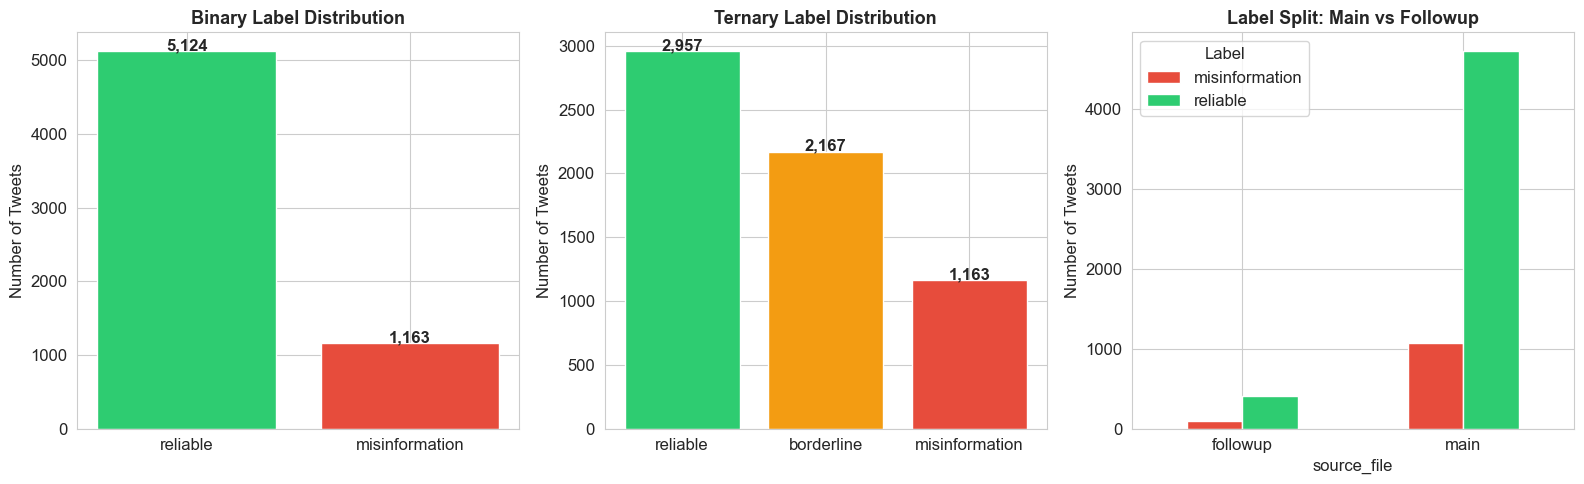

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Binary
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#2ecc71' if x == 'reliable' else '#e74c3c' for x in counts.index],
            edgecolor='white')
axes[0].set_title('Binary Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Tweets')
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', fontweight='bold')

# Ternary
counts3 = df['label_3'].value_counts()
color3 = {'reliable': '#2ecc71', 'borderline': '#f39c12', 'misinformation': '#e74c3c'}
axes[1].bar(counts3.index, counts3.values,
            color=[color3[x] for x in counts3.index], edgecolor='white')
axes[1].set_title('Ternary Label Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Tweets')
for bar, val in zip(axes[1].patches, counts3.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', fontweight='bold')

# Main vs Followup
src_counts = df.groupby(['source_file', 'label']).size().unstack(fill_value=0)
src_counts.plot(kind='bar', ax=axes[2],
                color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[2].set_title('Label Split: Main vs Followup', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Number of Tweets')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Label')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}mpox_01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Tweet Length Analysis

In [7]:
df['tweet_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print('Tweet length stats by label:')
print(df.groupby('label')[['tweet_length', 'word_count']].describe().round(1).to_string())

Tweet length stats by label:
               tweet_length                                                word_count                                         
                      count   mean   std   min    25%    50%    75%    max      count  mean   std  min   25%   50%   75%   max
label                                                                                                                         
misinformation       1163.0  174.0  97.3  20.0  102.0  160.0  238.5  807.0     1163.0  27.2  14.1  1.0  15.0  25.0  39.0  90.0
reliable             5124.0  127.9  79.6  10.0   67.0  101.0  180.0  769.0     5124.0  20.2  12.8  1.0  10.0  16.0  29.0  65.0


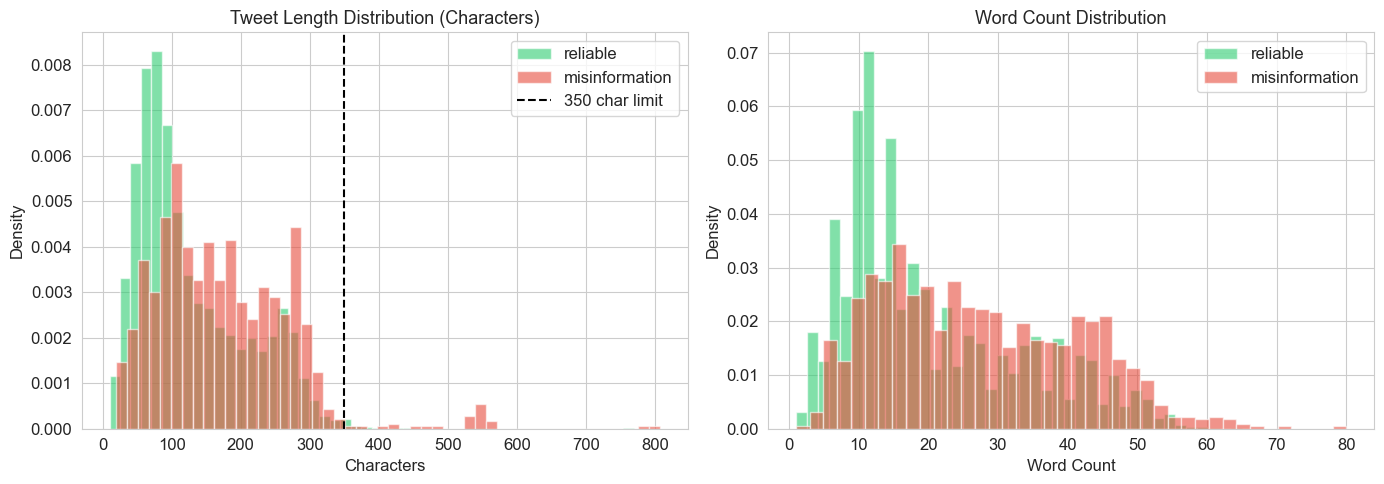

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [('reliable', '#2ecc71'), ('misinformation', '#e74c3c')]:
    subset = df[df['label'] == label]
    axes[0].hist(subset['tweet_length'], bins=50, alpha=0.6, label=label, color=color, density=True)
    axes[1].hist(subset['word_count'].clip(0, 80), bins=40, alpha=0.6, label=label, color=color, density=True)

axes[0].set_title('Tweet Length Distribution (Characters)', fontsize=13)
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Density')
axes[0].axvline(350, color='black', linestyle='--', label='350 char limit')
axes[0].legend()

axes[1].set_title('Word Count Distribution', fontsize=13)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}mpox_02_tweet_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Engagement Metrics

In [9]:
eng_cols = ['retweet_count', 'reply_count', 'like_count', 'quote_count']
print('Mean engagement by label:')
print(df.groupby('label')[eng_cols].mean().round(2))

Mean engagement by label:
                retweet_count  reply_count  like_count  quote_count
label                                                              
misinformation           2.37         0.95        9.29         0.20
reliable                 2.65         1.05       14.09         0.95


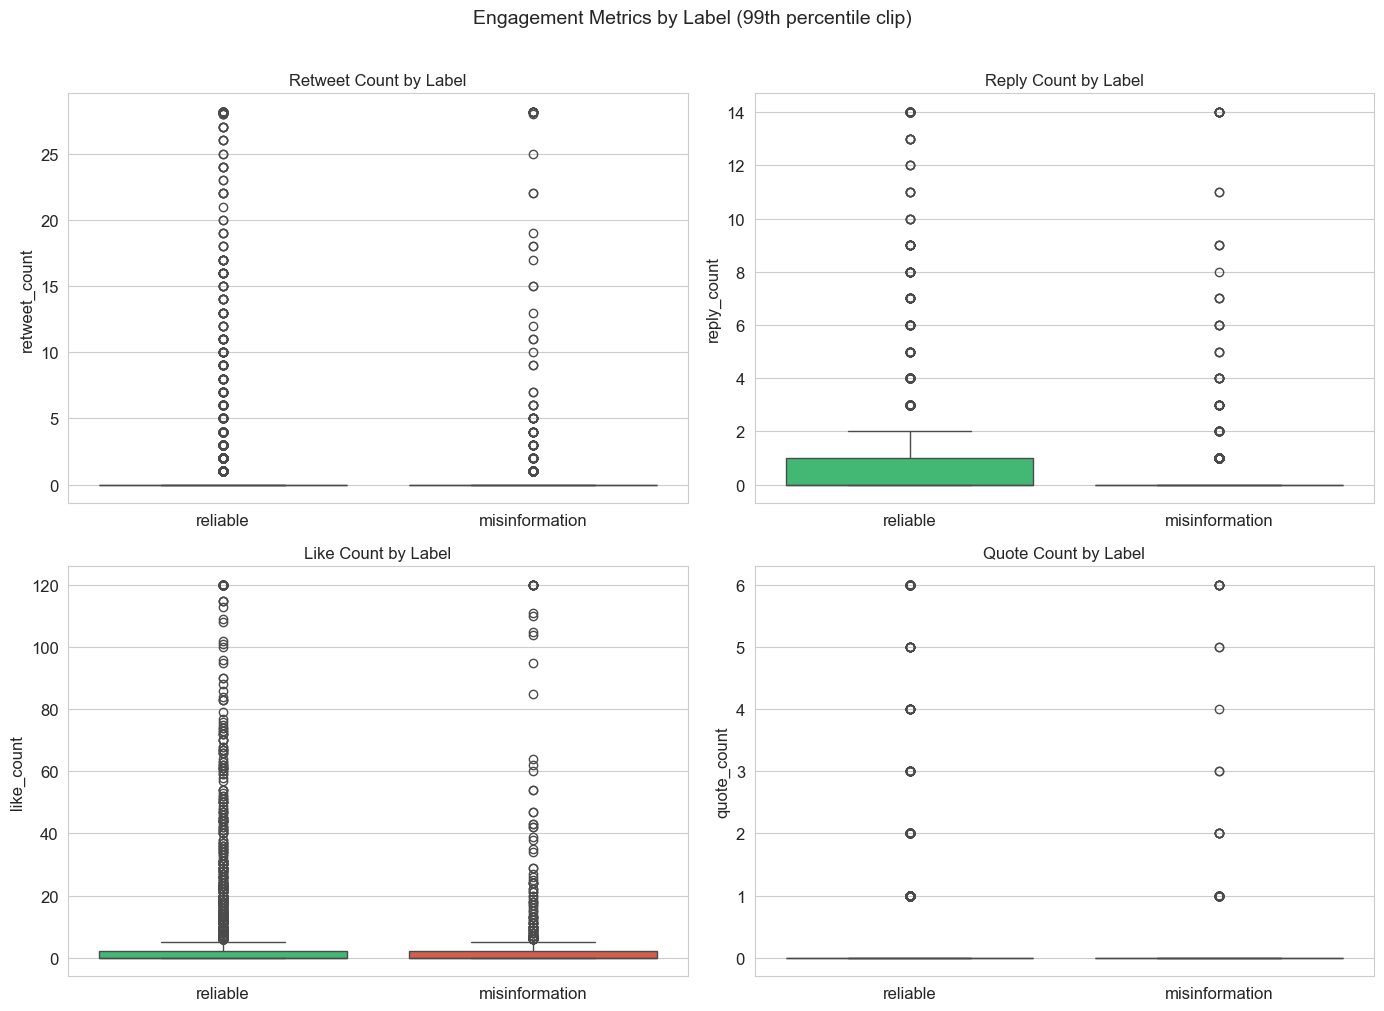

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(eng_cols):
    clipped = df[col].clip(upper=df[col].quantile(0.99))
    temp = df.copy()
    temp[col] = clipped
    sns.boxplot(data=temp, x='label', y=col, ax=axes[i],
                palette={'reliable': '#2ecc71', 'misinformation': '#e74c3c'})
    axes[i].set_title(f'{col.replace("_", " ").title()} by Label', fontsize=12)
    axes[i].set_xlabel('')

plt.suptitle('Engagement Metrics by Label (99th percentile clip)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}mpox_03_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. User Metadata

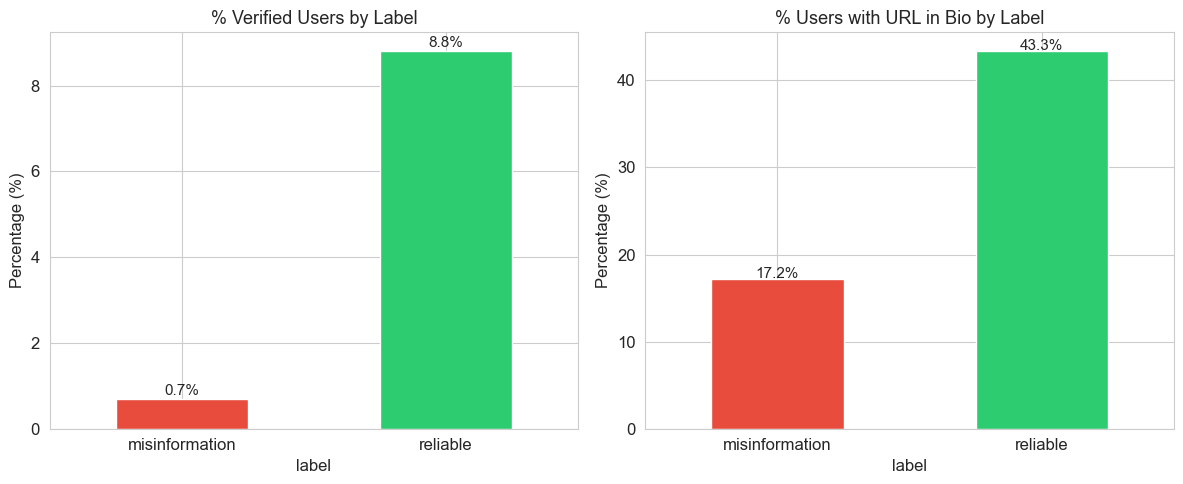

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Verified users
verified = df.groupby('label')['user is verified'].mean() * 100
verified.plot(kind='bar', ax=axes[0],
              color=['#2ecc71' if x == 'reliable' else '#e74c3c' for x in verified.index],
              edgecolor='white')
axes[0].set_title('% Verified Users by Label', fontsize=13)
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[0].patches, verified.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', fontsize=11)

# Has URL
has_url = df.groupby('label')['user has url'].mean() * 100
has_url.plot(kind='bar', ax=axes[1],
             color=['#2ecc71' if x == 'reliable' else '#e74c3c' for x in has_url.index],
             edgecolor='white')
axes[1].set_title('% Users with URL in Bio by Label', fontsize=13)
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[1].patches, has_url.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}mpox_04_user_metadata.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Top Words

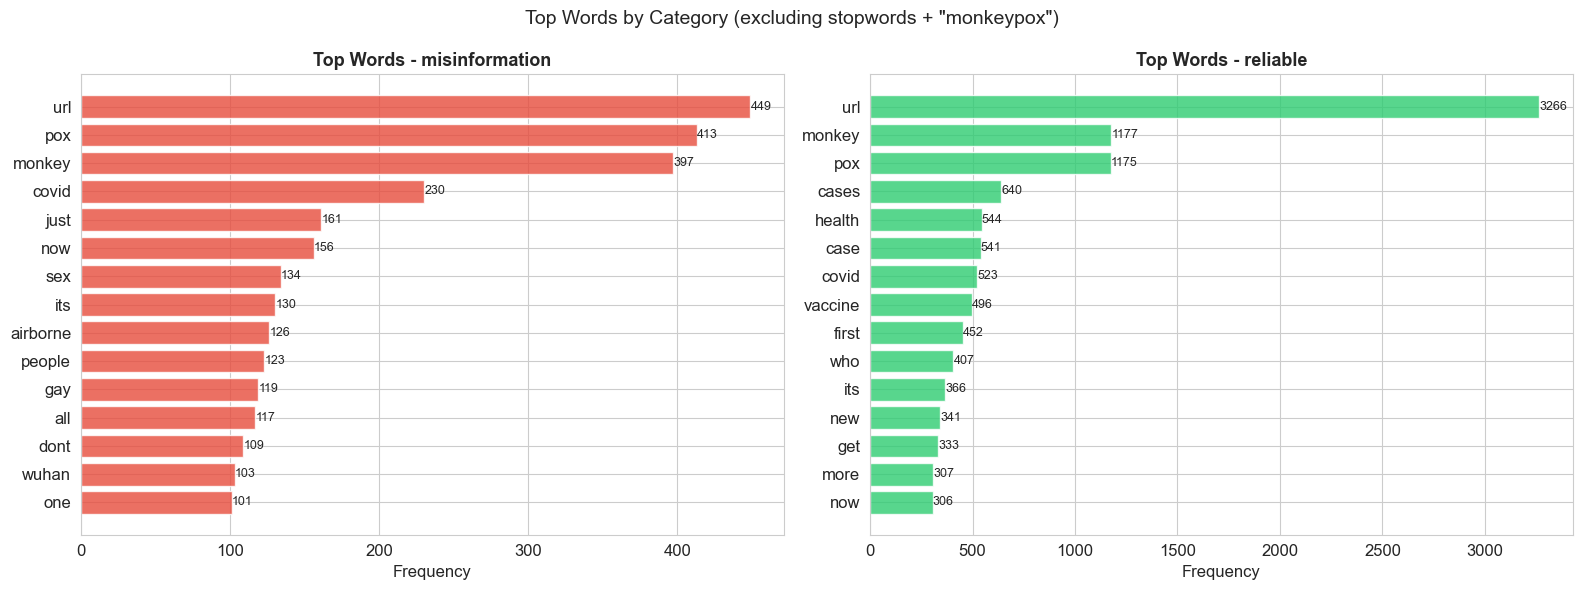

In [12]:
STOPWORDS = set(['the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to',
                  'for', 'of', 'with', 'is', 'it', 'this', 'that', 'are', 'was',
                  'were', 'be', 'been', 'have', 'has', 'had', 'do', 'does', 'did',
                  'will', 'would', 'could', 'should', 'may', 'might', 'i', 'you',
                  'he', 'she', 'we', 'they', 'my', 'your', 'his', 'her', 'our',
                  'their', 'not', 'no', 'so', 'if', 'as', 'by', 'from', 'up',
                  'about', 'into', 'through', 'rt', 'amp', 'monkeypox'])

def get_top_words(texts, n=15):
    words = []
    for text in texts:
        t = str(text).lower()
        t = re.sub(r'http\S+|@\w+|#(\w+)', r'\1', t)
        t = re.sub(r'[^a-z\s]', '', t)
        words.extend([w for w in t.split() if w not in STOPWORDS and len(w) > 2])
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, label, color in [(axes[0], 'misinformation', '#e74c3c'), (axes[1], 'reliable', '#2ecc71')]:
    top = get_top_words(df[df['label'] == label]['text'], n=15)
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Top Words - {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
    for bar, val in zip(ax.patches, counts[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)

plt.suptitle('Top Words by Category (excluding stopwords + "monkeypox")', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}mpox_05_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. t-SNE Visualization

Running TF-IDF...
Running t-SNE (~30 sec)...


  File "C:\Users\yoni1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Done.


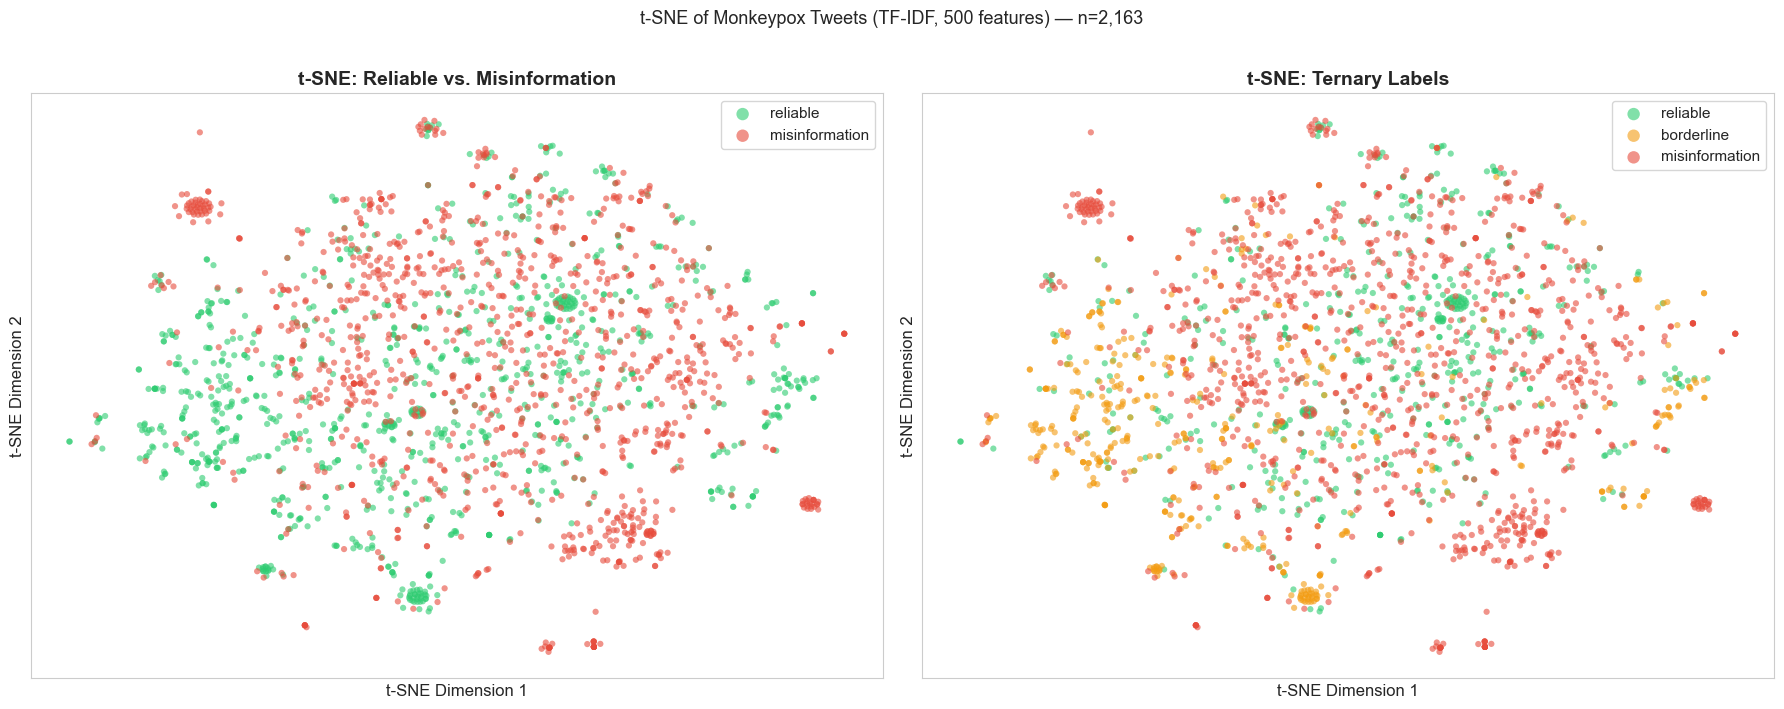

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

# Sample: all misinfo + equal sample of reliable
misinfo = df[df['label'] == 'misinformation']
reliable = df[df['label'] == 'reliable'].sample(min(len(misinfo), 1000), random_state=42)
tsne_df = pd.concat([misinfo, reliable], ignore_index=True)

def clean_for_tsne(text):
    t = str(text).lower()
    t = re.sub(r'http\S+|@\w+', '', t)
    t = re.sub(r'#(\w+)', r'\1', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

tsne_df['clean'] = tsne_df['text'].apply(clean_for_tsne)

print('Running TF-IDF...')
vectorizer = TfidfVectorizer(max_features=500, min_df=2, stop_words='english')
X = vectorizer.fit_transform(tsne_df['clean']).toarray()

print('Running t-SNE (~30 sec)...')
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_2d = tsne.fit_transform(X)

tsne_df['tsne_x'] = X_2d[:, 0]
tsne_df['tsne_y'] = X_2d[:, 1]
print('Done.')

# Plot 1: Binary label
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for label, color in [('reliable', '#2ecc71'), ('misinformation', '#e74c3c')]:
    mask = tsne_df['label'] == label
    axes[0].scatter(tsne_df.loc[mask, 'tsne_x'], tsne_df.loc[mask, 'tsne_y'],
                    c=color, label=label, alpha=0.6, s=20, edgecolors='none')
axes[0].set_title('t-SNE: Reliable vs. Misinformation', fontsize=14, fontweight='bold')
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')
axes[0].legend(markerscale=2, fontsize=11)
axes[0].set_xticks([]); axes[0].set_yticks([])

# Plot 2: Ternary label
color3 = {'reliable': '#2ecc71', 'borderline': '#f39c12', 'misinformation': '#e74c3c'}
for label, color in color3.items():
    mask = tsne_df['label_3'] == label
    if mask.sum() == 0: continue
    axes[1].scatter(tsne_df.loc[mask, 'tsne_x'], tsne_df.loc[mask, 'tsne_y'],
                    c=color, label=label, alpha=0.6, s=20, edgecolors='none')
axes[1].set_title('t-SNE: Ternary Labels', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].legend(markerscale=2, fontsize=11)
axes[1].set_xticks([]); axes[1].set_yticks([])

n_total = len(tsne_df)
plt.suptitle(f't-SNE of Monkeypox Tweets (TF-IDF, 500 features) — n={n_total:,}',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}mpox_06_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. EDA Summary

In [14]:
print('='*55)
print('EDA Summary - Monkeypox Dataset')
print('='*55)
print(f'Total tweets:        {len(df):,} (main: {len(df_main):,}, followup: {len(df_followup):,})')
print(f'Misinformation:      {(df["label"]=="misinformation").sum():,} ({(df["label"]=="misinformation").mean()*100:.1f}%)')
print(f'Reliable:            {(df["label"]=="reliable").sum():,} ({(df["label"]=="reliable").mean()*100:.1f}%)')
print(f'Borderline:          {(df["label_3"]=="borderline").sum():,}')
print(f'Avg tweet length:    {df["tweet_length"].mean():.0f} chars')
print(f'Avg word count:      {df["word_count"].mean():.0f} words')
print(f'Avg retweets:        {df["retweet_count"].mean():.1f}')
print(f'Verified users:      {df["user is verified"].mean()*100:.1f}%')
print('='*55)

EDA Summary - Monkeypox Dataset
Total tweets:        6,287 (main: 5,787, followup: 500)
Misinformation:      1,163 (18.5%)
Reliable:            5,124 (81.5%)
Borderline:          2,167
Avg tweet length:    136 chars
Avg word count:      21 words
Avg retweets:        2.6
Verified users:      7.3%
